# Configuration

Set the project root directory below (the root of the git repository that was cloned).

In [1]:
PROJECT_ROOT_DIR = 'C:/Users/sumit/GitRepos/FloodResearch/bhccpx/'

import os
import sys
os.chdir(os.path.join(PROJECT_ROOT_DIR, 'bhccpx'))
sys.path.append(os.path.join(PROJECT_ROOT_DIR, 'bhccpx'))

Place this same directory in `DEFAULT:rootdir` in the `bhccpx/BHCCPX.ini` configuration file.

In [2]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

import zipfile
import pickle as pkl

import bhc_datautil
from bhc_datautil import AsOfDate
import csv2sys
import sys2bhc
import bhc2out

In [3]:
config = bhc_datautil.read_config()

# Downloading Data

Go to the [FFIC NIC Data Download](https://www.ffiec.gov/npw/FinancialReport/DataDownload) site and download all of the CSV ZIP files. This step cannot be automated, as it may require a CAPTCHA.

Once you have done so, place them in the folder you specified in the `DEFAULT::datadir` directory. You can either unzip them manually (and place the CSV files in the same directory) or run the following utility.

In [ ]:
print(f"Data directory: {config.get('DEFAULT', 'datadir')}")

filenames = [
	'CSV_ATTRIBUTES_ACTIVE.zip',
	'CSV_ATTRIBUTES_BRANCHES.zip',
	'CSV_ATTRIBUTES_CLOSED.zip',
	'CSV_RELATIONSHIPS.zip',
	'CSV_TRANSFORMATIONS.zip',
]
for filename in filenames:
	zip_path = os.path.join(config.get('DEFAULT', 'datadir'), filename)
	if os.path.exists(zip_path):
		with zipfile.ZipFile(zip_path, 'r') as zip_ref:
			zip_ref.extractall(config.get('DEFAULT', 'datadir'))
		print(f"Extracted {zip_path}")

# Parsing the data

We next parse the raw CSV data into NetworkX objects, which are cached locally.  Parsing is an expensive operation, so it is highly desirable to cache the NetworkX objects as intermediate state.

Before running, be sure to check the following configuration options (note that if you change these, you should rerun the cell where the config is read):
- `DEFAULT:parallelcores`:  Each operation may take some time to complete if done sequentially (around 30 minutes with default settings). If you have a strong CPU with multiple cores, we recommend adjusting this option to take advantage of parallel processing
- `csv2sys:asofdate0` and `csv2sys:asofdate1`: these specify the range of asofdates (year/quarter) that will be processed
- `sys2bhc:asoflist`: similar to above; if the list is empty, it will use the same range as specified in `csv2sys`
- `sys2bhc:bhclist`: a list of RSSDs to process; if it is `None`, then all available RSSDs will be processed
- `csv2sys:clearcache` and `sys2bhc:clearcache`: these are `True` by default, so you should only run these cells once

In [ ]:
csv2sys.main(argv=['csv2sys.py'])

In [ ]:
sys2bhc.main(argv=['sys2bhc.py'])

# SVB Analysis
As an example, we will track **SVB Financial Group** (RSSD=1031449) from its inception in 1983 as **Silicon Valley Bancshares** to its collapse in 2023. 

From the cache, we extract SVB's hierarchy objects each quarter for the 40 years (1983-2023). For each hiearchy, we calculate a variety of complexity statistics. 

In [4]:
SVB_rssd = 1031449
asoflist = bhc_datautil.AsOfDate.make_range_from_YQ_strs(config.get('csv2sys', 'asofdate0'), config.get('csv2sys', 'asofdate1'))
print(f"All quarters from {config.get('csv2sys', 'asofdate0')} to {config.get('csv2sys', 'asofdate1')}")

All quarters from 1983Q4 to 2022Q4


In [5]:
df = bhc2out.make_wachwells_comparison([(SVB_rssd, asofdate) for asofdate in asoflist], config=config)

INFO::root::91 - Creating BHC networks
INFO::root::106 - *** Processing Table2 Complete ***


In [6]:
def get_summary_statistics(df: pd.DataFrame, excluded_columns: list[str]) -> pd.DataFrame:
	cols = [col for col in df.columns if col not in excluded_columns]
	summary = pd.DataFrame(columns=['mean', 'std', 'min', '5%', '10%', '25%', '50%', '75%', '90%', '95%', 'max'], dtype=int)
	for col in cols:
		arr = df[col].values
		metrics = [arr.mean(), arr.std(ddof=1), arr.min()] + list(np.percentile(arr, [5, 10, 25, 50, 75, 90, 95])) + [arr.max()]
		summary.loc[col] = metrics
	for colname in ['min', '5%', '10%', '25%', '50%', '75%', '90%', '95%', 'max']:
		summary[colname] = summary[colname].astype(int)
	return summary

In [7]:
get_summary_statistics(df, excluded_columns=['rssd', 'asofdate'])

,mean,std,min,5%,10%,25%,50%,75%,90%,95%,max
Bas_Vertex_count,39.261146,45.714856,2,3,3,3,23,59,97,146,195
Bas_Edge_count,51.777070,63.927703,1,2,2,2,25,79,138,206,259
Bas_Cycle_rank,13.515924,18.361961,0,0,0,0,3,21,42,61,66
Bas_Num_CComp,1.000000,0.000000,1,1,1,1,1,1,1,1,1
Ent_Qfull_B1,48.299363,62.695997,0,0,0,0,22,74,132,200,254
Ent_Qhetr_B1,19.923567,21.450163,0,0,0,0,14,36,43,54,90
Ent_Qfcon_B1,2.707006,2.473607,0,0,0,0,2,5,6,7,7
Ent_Qhcon_B1,1.719745,1.647976,0,0,0,0,1,3,4,5,5
Ent_edgcn_B1,0.573248,0.690632,0,0,0,0,0,1,2,2,2
Ent_DjHom_B1,5.114650,10.001902,0,0,0,0,0,6,18,35,39


# Correlations with G-SIB Indicators

Download the [FR Y-15 Snapshot Reports](https://www.ffiec.gov/npw/FinancialReport/FRY15Reports) from the FFEIC website. Place them in the `bhccpx/data/` directory, and rename them to `fy15_YYYY.csv`, where YYYY is the year of the report.

Note that the reports currently available are not the same as those used in the original BHCCPX paper, so the available data points and exact correlation values will be slightly different.

In [8]:
y15_by_year = {}
for year in range(2019, 2023+1):
	df = pd.read_csv(os.path.join(config.get('DEFAULT', 'datadir'), f'fy15_{year}.csv'))
	if 'Name (Legal)' in df.columns:
		df.rename(columns={'Name (Legal)': 'NAME'}, inplace=True)
	df.NAME = df.NAME.astype('string')
	if 'DT' in df.columns:
		df.DT = pd.to_datetime(df.DT, format='%Y%m%d')
		df.rename(columns={'DT': 'AsOfDate'}, inplace=True)
	else:
		df.AsOfDate = pd.to_datetime(df.AsOfDate, format='%m/%d/%Y')
	y15_by_year[year] = df

In [9]:
def get_indicator_helper(df: pd.DataFrame, rssd: int, indicator: str) -> float:
	a = float(df.loc[df['ID_RSSD'] == rssd, "RISK"+indicator].values[0])
	if not pd.isnull(a):
		return a
	if 'RISI'+indicator not in df.columns or 'RISO'+indicator not in df.columns:
		return 0.0
	b = float(df.loc[df['ID_RSSD'] == rssd, "RISI"+indicator].values[0])
	c = float(df.loc[df['ID_RSSD'] == rssd, "RISO"+indicator].values[0])
	return (b if not pd.isnull(b) else 0) + (c if not pd.isnull(c) else 0)

In [10]:
def get_size(rssd: int, year: int) -> float:
	df = y15_by_year[year]
	return get_indicator_helper(df, rssd, 'Y832')

def get_interconnectedness(rssd: int, year: int) -> float:
	df = y15_by_year[year]
	a = get_indicator_helper(df, rssd, 'M362')
	b = get_indicator_helper(df, rssd, 'M370')
	c = get_indicator_helper(df, rssd, 'M376')
	return (a + b + c) / 3

def get_substitutability(rssd: int, year: int) -> float:
	df = y15_by_year[year]
	a = get_indicator_helper(df, rssd, 'M390')
	b = get_indicator_helper(df, rssd, 'M405')
	c = get_indicator_helper(df, rssd, 'M408')
	return (a + b + c) / 3

def get_complexity(rssd: int, year: int) -> float:
	df = y15_by_year[year]
	a = get_indicator_helper(df, rssd, 'M411')
	b = get_indicator_helper(df, rssd, 'N255')
	c = get_indicator_helper(df, rssd, 'G506')
	return (a + b + c) / 3

def get_crossjurisdictional(rssd: int, year: int) -> float:
	df = y15_by_year[year]
	a = get_indicator_helper(df, rssd, 'M422')
	b = get_indicator_helper(df, rssd, 'M426')
	return (a + b) / 2

In [11]:
valid_pairs = set() # (RSSD, year)
for year in range(2019, 2023+1):
	for _, row in y15_by_year[year].iterrows():
		bhcfilename = 'BHC_'+str(row.ID_RSSD)+'_'+str(year)+'1231.pkl'
		bhcfilepath = os.path.join(config.get('sys2bhc', 'outdir'), bhcfilename)
		if os.path.exists(bhcfilepath):
			valid_pairs.add((row.ID_RSSD, year))

In [12]:
df = bhc2out.make_wachwells_comparison([(rssd, AsOfDate.from_str(f"{yyyy}1231")) for rssd, yyyy in valid_pairs], config=config)

INFO::root::91 - Creating BHC networks
INFO::root::106 - *** Processing Table2 Complete ***


In [13]:
df['g15_size'] = df.apply(lambda row: get_size(row.rssd, int(row.asofdate[:4])), axis=1)
df['g15_interconnectedness'] = df.apply(lambda row: get_interconnectedness(row.rssd, int(row.asofdate[:4])), axis=1)
df['g15_substitutability'] = df.apply(lambda row: get_substitutability(row.rssd, int(row.asofdate[:4])), axis=1)
df['g15_complexity'] = df.apply(lambda row: get_complexity(row.rssd, int(row.asofdate[:4])), axis=1)
df['g15_crossjurisdictional'] = df.apply(lambda row: get_crossjurisdictional(row.rssd, int(row.asofdate[:4])), axis=1)
df['g15_systemic'] = (df.g15_size + df.g15_interconnectedness + df.g15_substitutability + df.g15_complexity + df.g15_crossjurisdictional) / 5

The top half of Table 3 is the correlations between the G-SIB indicators.

In [14]:
df[['g15_size', 'g15_interconnectedness', 'g15_substitutability', 'g15_complexity', 'g15_crossjurisdictional', 'g15_systemic']].corr()

,g15_size,g15_interconnectedness,g15_substitutability,g15_complexity,g15_crossjurisdictional,g15_systemic
g15_size,1.000000,0.961647,0.748678,0.917501,0.850523,0.801536
g15_interconnectedness,0.961647,1.000000,0.826213,0.935727,0.886367,0.871935
g15_substitutability,0.748678,0.826213,1.000000,0.711825,0.754957,0.995321
g15_complexity,0.917501,0.935727,0.711825,1.000000,0.926347,0.775970
g15_crossjurisdictional,0.850523,0.886367,0.754957,0.926347,1.000000,0.804900
g15_systemic,0.801536,0.871935,0.995321,0.775970,0.804900,1.000000


The bottom half is the correlations with the BHCCPX metrics.

In [15]:
df.corr().iloc[2:-6, -6:]

,g15_size,g15_interconnectedness,g15_substitutability,g15_complexity,g15_crossjurisdictional,g15_systemic
Bas_Vertex_count,0.395553,0.407394,0.152734,0.460230,0.369657,0.200252
Bas_Edge_count,0.355751,0.376725,0.121141,0.440401,0.345627,0.168661
Bas_Cycle_rank,0.191018,0.236966,0.010541,0.325433,0.229815,0.052126
Bas_Num_CComp,NaN,NaN,NaN,NaN,NaN,NaN
Ent_Qfull_B1,0.354666,0.375530,0.119890,0.439464,0.344410,0.167405
Ent_Qhetr_B1,0.601190,0.588789,0.255940,0.672997,0.542046,0.322440
Ent_Qfcon_B1,0.690785,0.731666,0.601734,0.664279,0.738578,0.633500
Ent_Qhcon_B1,0.682502,0.725055,0.591954,0.666845,0.756451,0.624945
Ent_edgcn_B1,0.541605,0.590566,0.378964,0.624295,0.532412,0.425084
Ent_DjHom_B1,0.127935,0.152479,-0.006812,0.200953,0.151843,0.020666


In [16]:
df.g15_size = df.g15_size / 10**7
df.g15_interconnectedness = df.g15_interconnectedness / 10**7
df.g15_substitutability = df.g15_substitutability / 10**7
df.g15_complexity = df.g15_complexity / 10**7
df.g15_crossjurisdictional = df.g15_crossjurisdictional / 10**7
df.g15_systemic = df.g15_systemic / 10**7

We outline how to perform the regressions from Table 5 of the paper. As an example, we perform regression IV; the others can be done in a similar manner.

In [17]:
import statsmodels.api as sm
# Prepare the data for regression
reg_df = df[['g15_interconnectedness', 'g15_size', 'Bas_Cycle_rank']].dropna()
X = reg_df[['g15_size', 'Bas_Cycle_rank']]
X = sm.add_constant(X)  # Adds intercept term
y = reg_df['g15_interconnectedness']
model = sm.OLS(y, X).fit()
print(model.summary())

                              OLS Regression Results                              
Dep. Variable:     g15_interconnectedness   R-squared:                       0.928
Model:                                OLS   Adj. R-squared:                  0.926
Method:                     Least Squares   F-statistic:                     616.0
Date:                    Mon, 05 Jan 2026   Prob (F-statistic):           1.72e-55
Time:                            16:24:52   Log-Likelihood:                -256.99
No. Observations:                      99   AIC:                             520.0
Df Residuals:                          96   BIC:                             527.8
Df Model:                               2                                         
Covariance Type:                nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
cons

# Wells and Wachovia

Next, we want to recreate the case study found in Appendix B. Of the paper. We recreate Table B.3 which compares the complexity of Wells Fargo and Wachovia in the years before the acquisition.

In [18]:
wells_rssd = 1120754
wachovia_rssd = 1073551

In [19]:
df = bhc2out.make_wachwells_comparison([
	(wells_rssd, '20061231'), (wachovia_rssd, '20061231'),
	(wells_rssd, '20080930'), (wachovia_rssd, '20080930'),
	(wells_rssd, '20081231'), # (wachovia_rssd, '20101231')
], config=config).T
df.columns = [
	'Wachovia Q4 2006', 'Wachovia Q3 2008', # 'Wachovia Q4 2010',
	'Wells F. Q4 2006', 'Wells F. Q3 2008', 'Wells F. Q4 2008',
]
df[['Wells F. Q4 2006', 'Wachovia Q4 2006', 'Wells F. Q3 2008', 'Wachovia Q3 2008', 'Wells F. Q4 2008']]

INFO::root::91 - Creating BHC networks
INFO::root::106 - *** Processing Table2 Complete ***


,Wells F. Q4 2006,Wachovia Q4 2006,Wells F. Q3 2008,Wachovia Q3 2008,Wells F. Q4 2008
rssd,1120754,1073551,1120754,1073551,1120754
asofdate,20061231,20061231,20080930,20080930,20081231
Bas_Vertex_count,615,1385,620,1037,1720
Bas_Edge_count,654,1674,653,1441,2169
Bas_Cycle_rank,40,290,34,405,450
Bas_Num_CComp,1,1,1,1,1
Ent_Qfull_B1,640,1659,639,1427,2153
Ent_Qhetr_B1,225,452,235,672,992
Ent_Qfcon_B1,16,17,18,18,27
Ent_Qhcon_B1,12,14,14,14,22


Finally, we recreate the complexity-time graphs in Figure B.5.

In [20]:
asoflist = bhc_datautil.AsOfDate.make_range_from_YQ_strs('1986Q1', '2016Q4')
df = bhc2out.make_wachwells_comparison([(wells_rssd, asofdate) for asofdate in asoflist], config=config)

INFO::root::91 - Creating BHC networks
INFO::root::106 - *** Processing Table2 Complete ***


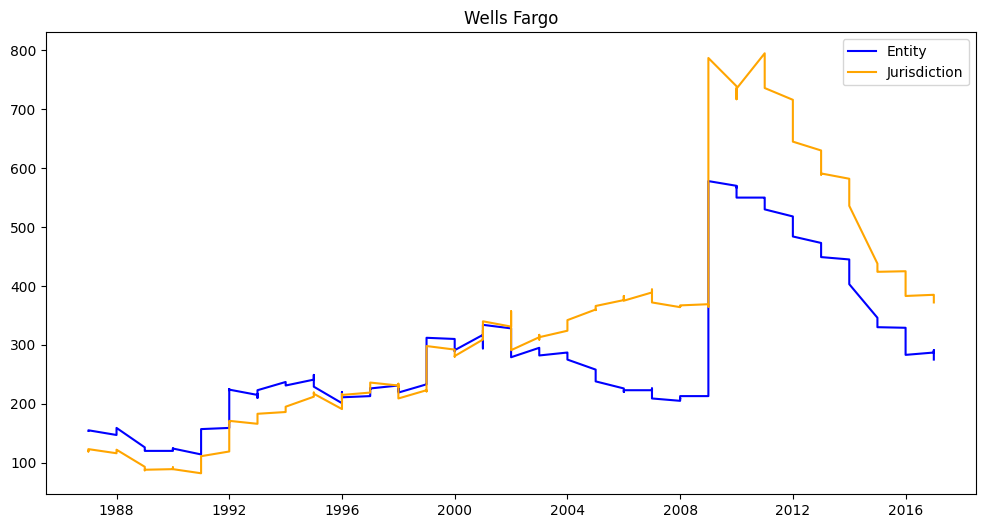

In [21]:
plt.figure(figsize=(12, 6))
time = df.asofdate.astype('string').map(lambda d: pd.to_datetime(d[:4] + ('0331' if d == 1 else '0630' if d == 2 else '0930' if d == 3 else '1231'), format='%Y%m%d'))
plt.plot(time, df.Ent_DjHom_M, label='Entity', c='blue')
plt.plot(time, df.Geo_DjHom_M, label='Jurisdiction', c='orange')
plt.legend()
plt.title('Wells Fargo')
plt.show()

In [23]:
asoflist = bhc_datautil.AsOfDate.make_range_from_YQ_strs('1986Q1', '2008Q3')
for asofdate in map(AsOfDate.from_int, [19960331, 19960630, 19960930, 19961231, 19970331, 19970630, 19970930, 19971231]):
	asoflist.remove(asofdate)
df = bhc2out.make_wachwells_comparison([(wachovia_rssd, asofdate) for asofdate in asoflist], config=config)

INFO::root::91 - Creating BHC networks
INFO::root::106 - *** Processing Table2 Complete ***


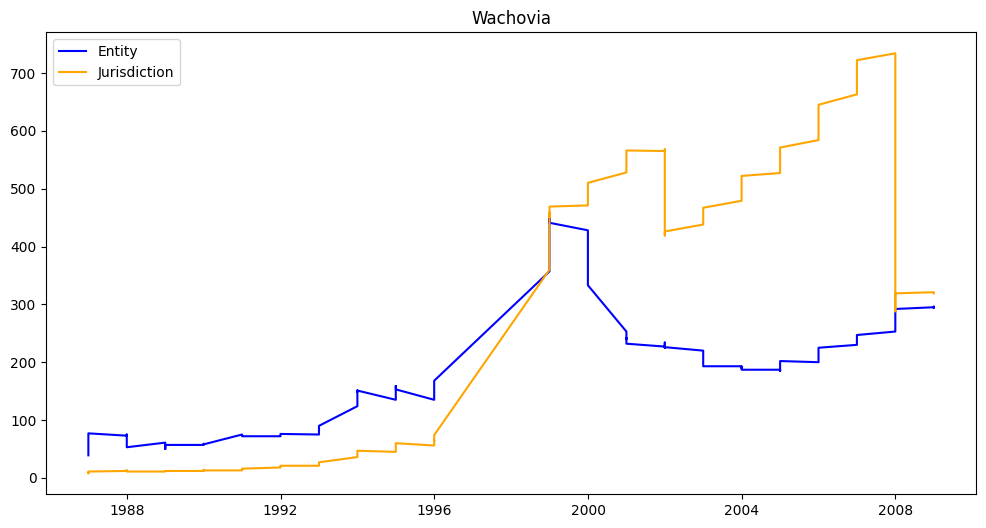

In [24]:
plt.figure(figsize=(12, 6))
time = df.asofdate.astype('string').map(lambda d: pd.to_datetime(d[:4] + ('0331' if d == 1 else '0630' if d == 2 else '0930' if d == 3 else '1231'), format='%Y%m%d'))
plt.plot(time, df.Ent_DjHom_M, label='Entity', c='blue')
plt.plot(time, df.Geo_DjHom_M, label='Jurisdiction', c='orange')
plt.legend()
plt.title('Wachovia')
plt.show()